In [18]:
import numpy as np
from numpy import random as rnd
from matplotlib import pyplot as plt
from scipy.fft import fft, ifft, dct
from scipy.integrate import ode
from scipy.optimize import bisect
from tqdm import autonotebook as tqdm

In [9]:
def numerov(x, v, energy):
    g = energy - v
    dx = x[1] - x[0]
    psi = np.zeros_like(x)
    psi[1] = 1e-2
    for k in range(1, x.shape[0]-1):
        k_plus = (1 + 1./12. * dx * dx * g[k + 1])
        k_zero = (1 - 5./12. * dx * dx * g[k])
        k_minus = (1 + 1./12. * dx * dx * g[k - 1])
        psi[k+1] = (2 * psi[k] * k_zero - psi[k - 1] * k_minus) / k_plus
    return psi


def refine_energy(x, v, e0, e1):
    def last_wave_function_point(energy):
        psi = numerov(x, v, energy)
        return psi[-1]
    return bisect(last_wave_function_point, e0, e1)

def find_energies(x, v):
    last_energy = v.min()
    last_psi = numerov(x, v, last_energy)
    for energy in np.linspace(v.min()+1e-5, 0, 101):
        psi = numerov(x, v, energy)
        if psi[-1] * last_psi[-1] < 0:
            final_energy = refine_energy(x, v, last_energy, energy)
            yield final_energy, numerov(x, v, final_energy)
        last_energy = energy
        last_psi = psi

In [10]:
def random_potential(df, num_bins, rise, decay, min_val):
    x = np.linspace(0, 1, num_bins)
    before_x = np.linspace(-1, x[0]-(x[1]-x[0]), num_bins)
    after_x = np.linspace(x[-1] + x[1]-x[0], 2, num_bins)
    
    mu = rnd.standard_t(df)
    sigma = rnd.chisquare(df)
    y = rnd.normal(mu, sigma, size=num_bins) * np.exp(-x * decay * num_bins) * (x ** rise)
    
    yb = np.real(dct(y, typ=)) # dct(dct(x, type=2, norm='ortho'), type=3, norm='ortho')dct(dct(x, type=2, norm='ortho'), type=3, norm='ortho')
    yb = yb - yb[0]
    if np.abs(yb.min()) < np.abs(yb.max()):
        yb = - yb
    yb = min_val * yb / np.abs(yb.min())
    
    return np.r_[before_x, x, after_x], np.r_[np.zeros_like(before_x), yb, np.zeros_like(after_x)]

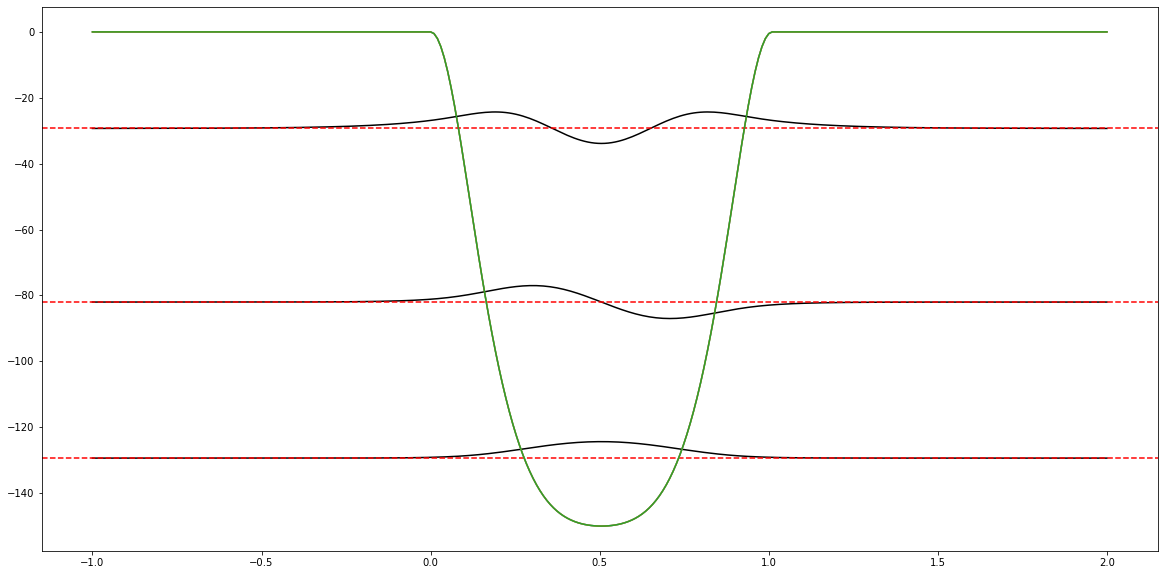

In [13]:
x, v = random_potential(2, 100, 0.5, 1.5, 150)

fig, ax = plt.subplots(figsize=(20, 10))
for (energy, psi) in find_energies(x, v):
    ax.plot(x, energy + psi/psi.max() * 5, color="black")
    ax.axhline(energy, color="red", linestyle="dashed")
    ax.plot(x, v)

$$
\begin{align}
    \frac{d\phi}{dx} &= (V(x) - E)\psi \\
    \frac{d\psi}{dx} &= \phi
\end{align}
$$

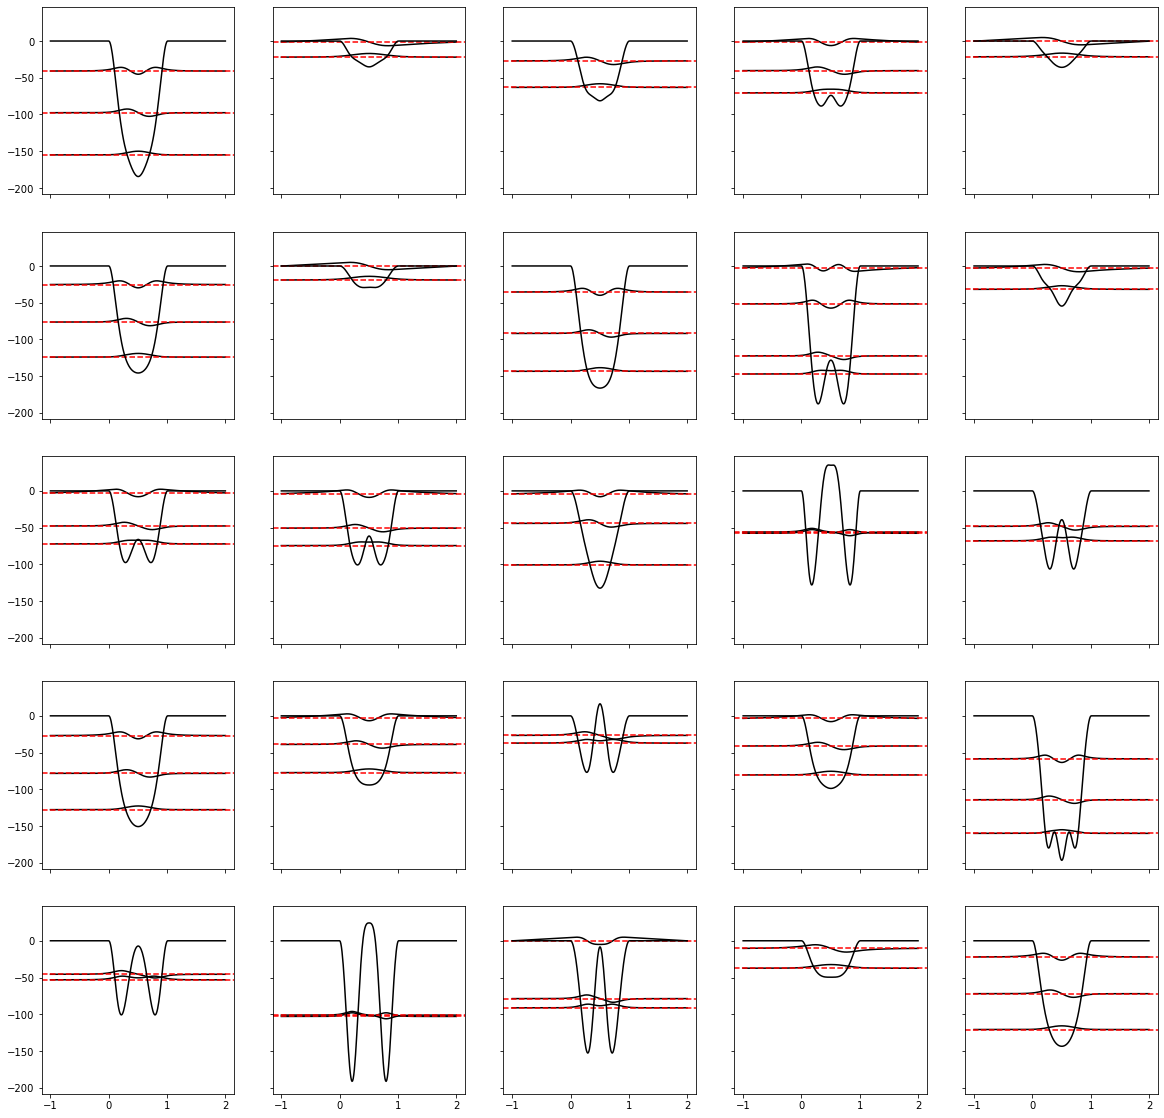

In [49]:
fig, ax = plt.subplots(nrows=5, ncols=5, figsize=(20, 20), sharex=True, sharey=True)
for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        min_val = rnd.uniform(10, 200)
        x, v = random_potential(2.0, 100, 0.5, 1.5, min_val)
        for (energy, psi) in find_energies(x, v):
            ax[i, j].plot(x, energy + psi/psi.max() * 5, color="black")
            ax[i, j].axhline(energy, color="red", linestyle="dashed")
        ax[i, j].plot(x, v, color="black")

In [59]:
N_examples = 10000
N_points = 100

outputs = []


for k in tqdm.trange(N_examples):
    min_val = rnd.uniform(10, 200)
    x, v = random_potential(2.0, N_points, 0.5, 1.5, min_val)
    results = list(find_energies(x, v))
    if len(results) > 0:
        outputs.append({
            "space": x.tolist(),
            "potential": v.tolist(),
            "states": [
                {"energy": energy, "wave_function": wave_function}
                for (energy, wave_function) in results
            ]
        })

  0%|          | 0/10000 [00:00<?, ?it/s]

In [60]:
import pickle

In [61]:
with open("data/dataset.bin", mode="wb") as fh:
    pickle.dump(outputs, fh)